# Soiling Analysis Options Comparison

This notebook demonstrates the impact of the soiling analysis parameters in RdTools v3.

## New Parameters in v3

| Parameter | Default | Description |
|-----------|---------|-------------|
| `detect_neg_shifts` | `False` | Detect negative shifts in rolling median to subdivide intervals |
| `piecewise_fit` | `False` | Test for slope change points within intervals |
| `neg_shift_factor` | `2.5` | Multiplier of `clean_threshold` for negative shift detection (only when `detect_neg_shifts=True`) |
| `min_piecewise_days` | `27` | Minimum interval length in days to attempt piecewise fitting (only when `piecewise_fit=True`) |
| `collapse_window_days` | `5` | Window for collapsing consecutive cleaning events into single event |
| `forward_median_window` | `10` | Window for forward median validation (only when `detect_neg_shifts=True`) |

## Renamed Parameters (v2 → v3)

| Old Name (v2) | New Name (v3) | Default |
|---------------|---------------|---------|
| `min_interval_length` | `min_interval_days` | `7` |
| `max_negative_step` | `max_neg_step` | `0.05` |
| `neg_shift` | `detect_neg_shifts` | `False` |
| `piecewise` | `piecewise_fit` | `False` |

## Removed Methods (Consolidated)

| Old Method (v2) | New Equivalent (v3) |
|-----------------|---------------------|
| `perfect_clean_complex` | `method='perfect_clean'` + `detect_neg_shifts=True` + `piecewise_fit=True` |
| `inferred_clean_complex` | `method='inferred_clean'` + `detect_neg_shifts=True` + `piecewise_fit=True` |

## Cleaning Methods

| Method | Description |
|--------|-------------|
| `half_norm_clean` | Starting point from half-normal distribution (default) |
| `random_clean` | Random recovery 0-100% |
| `perfect_clean` | Each cleaning returns performance to 1 |
| `inferred_clean` | Recovery inferred from data fits (requires `detect_neg_shifts=True`) |

## Approach

We build a master configuration DataFrame containing all parameter combinations, run each configuration, and then analyze the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import rdtools
from rdtools import soiling

c:\Users\mspringe\.conda\envs\rdtools_313-nb\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Data

In [ ]:
# Load example data from PVDAQ system 4
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)

# Rename columns and set up metadata
df = df.rename(columns={
    'ac_power': 'power_ac',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

meta = {'latitude': 39.7406,
        'longitude': -105.1774,
        'timezone': 'Etc/GMT+7',
        'gamma_pdc': -0.005,
        'azimuth': 180,
        'tilt': 40,
        'power_dc_rated': 1000.0,
        'temp_model_params': 'open_rack_glass_polymer'}

df.index = df.index.tz_localize(meta['timezone'])
freq = pd.infer_freq(df.index[:10])

# Apply synthetic soiling signal
df['power'] = df['power_ac'] * df['soiling']

# Create TrendAnalysis object for proper data preparation
ta = rdtools.TrendAnalysis(df['power'], df['poa'],
                           temperature_ambient=df['Tamb'],
                           gamma_pdc=meta['gamma_pdc'],
                           interp_freq=freq,
                           windspeed=df['wind_speed'],
                           power_dc_rated=meta['power_dc_rated'],
                           temperature_model=meta['temp_model_params'])

# Run normalization and aggregation
ta.sensor_analysis(analyses=['yoy_degradation'])

# Get aggregated daily data
energy_normalized_daily = ta.sensor_aggregated_performance
insolation_daily = ta.poa_global.resample('D').sum()
insolation_daily = insolation_daily.reindex(energy_normalized_daily.index)

# Generate synthetic precipitation for demonstration
np.random.seed(42)
precip_probs = np.random.random(len(energy_normalized_daily))
precipitation_daily = pd.Series(
    np.where(precip_probs > 0.85, np.random.uniform(1, 20, len(energy_normalized_daily)), 0),
    index=energy_normalized_daily.index,
    name='precipitation_daily'
)

print(f"Data range: {energy_normalized_daily.index[0]} to {energy_normalized_daily.index[-1]}")
print(f"Days: {len(energy_normalized_daily)}")

Data range: 2010-02-25 00:00:00-07:00 to 2016-12-13 00:00:00-07:00
Days: 2484


## Define Master Configuration

We define all the parameter combinations we want to explore. Each row represents one analysis configuration.

In [3]:
# Define parameter values to explore
# Using dictionaries to define parameter space

# Core boolean options
detect_neg_shifts_values = [False, True]
piecewise_fit_values = [False, True]

# Method options
# Note: 'inferred_clean' requires detect_neg_shifts=True
# Note: 'random_clean' is not tested here as it's mainly for comparison
method_values = ['half_norm_clean', 'perfect_clean', 'inferred_clean']

# Numeric parameters with their test values
neg_shift_factor_values = [1.5, 2.5, 4.0]  # default is 2.5
min_piecewise_days_values = [14, 27, 45]  # default is 27
collapse_window_days_values = [1, 5, 10]  # default is 5
forward_median_window_values = [5, 10, 20]  # default is 10

# Clean criterion options
clean_criterion_values = ['shift', 'precip', 'precip_and_shift', 'precip_or_shift']

# Default values for reference (matching soiling.py defaults)
DEFAULTS = {
    'method': 'half_norm_clean',
    'detect_neg_shifts': False,
    'piecewise_fit': False,
    'neg_shift_factor': 2.5,
    'min_piecewise_days': 27,
    'collapse_window_days': 5,
    'forward_median_window': 10,
    'clean_criterion': 'shift',
    # Additional defaults from soiling.py (not varied in this comparison):
    # 'min_interval_days': 7,
    # 'max_neg_step': 0.05 (only used when detect_neg_shifts=False),
    # 'max_relative_slope_error': 500.0,
    # 'outlier_factor': 1.5,
    # 'day_scale': 13,
    # 'clean_threshold': 'infer',
}

print("Default configuration:")
for k, v in DEFAULTS.items():
    print(f"  {k}: {v}")

Default configuration:
  method: half_norm_clean
  detect_neg_shifts: False
  piecewise_fit: False
  neg_shift_factor: 2.5
  min_piecewise_days: 27
  collapse_window_days: 5
  forward_median_window: 10
  clean_criterion: shift


In [4]:
# Build master configuration DataFrame
# Strategy: Full factorial - all parameter combinations × all methods

configs = []
config_counter = 0

# Define all methods to test
# Note: random_clean does not support detect_neg_shifts
all_methods = ['half_norm_clean', 'perfect_clean', 'inferred_clean']

# 1. Core options: detect_neg_shifts × piecewise_fit × method
for dns, pw in product([False, True], [False, True]):
    for method in all_methods:
        # inferred_clean requires detect_neg_shifts=True
        if method == 'inferred_clean' and not dns:
            continue
        config_counter += 1
        configs.append({
            'config_id': config_counter,
            'config_name': f'{method}_dns={dns}_pw={pw}',
            'config_group': 'core_matrix',
            **{**DEFAULTS, 'method': method, 'detect_neg_shifts': dns, 'piecewise_fit': pw}
        })

# 2. neg_shift_factor variations (requires detect_neg_shifts=True) × method
for val in neg_shift_factor_values:
    for method in all_methods:
        if method == 'inferred_clean' or True:  # all require dns=True for this param
            config_counter += 1
            configs.append({
                'config_id': config_counter,
                'config_name': f'{method}_nsf={val}',
                'config_group': 'neg_shift_factor',
                **{**DEFAULTS, 'method': method, 'detect_neg_shifts': True,
                   'neg_shift_factor': val}
            })

# 3. min_piecewise_days variations (requires piecewise_fit=True) × method
for val in min_piecewise_days_values:
    for method in all_methods:
        # inferred_clean requires detect_neg_shifts=True
        dns = True if method == 'inferred_clean' else False
        config_counter += 1
        configs.append({
            'config_id': config_counter,
            'config_name': f'{method}_mpd={val}',
            'config_group': 'min_piecewise_days',
            **{**DEFAULTS, 'method': method, 'detect_neg_shifts': dns,
               'piecewise_fit': True, 'min_piecewise_days': val}
        })

# 4. collapse_window_days variations × method
for val in collapse_window_days_values:
    for method in all_methods:
        # inferred_clean requires detect_neg_shifts=True
        dns = True if method == 'inferred_clean' else False
        config_counter += 1
        configs.append({
            'config_id': config_counter,
            'config_name': f'{method}_cwd={val}',
            'config_group': 'collapse_window_days',
            **{**DEFAULTS, 'method': method, 'detect_neg_shifts': dns,
               'collapse_window_days': val}
        })

# 5. forward_median_window variations (requires detect_neg_shifts=True) × method
for val in forward_median_window_values:
    for method in all_methods:
        config_counter += 1
        configs.append({
            'config_id': config_counter,
            'config_name': f'{method}_fmw={val}',
            'config_group': 'forward_median_window',
            **{**DEFAULTS, 'method': method, 'detect_neg_shifts': True,
               'forward_median_window': val}
        })

# 6. clean_criterion variations × method
for val in clean_criterion_values:
    for method in all_methods:
        # inferred_clean requires detect_neg_shifts=True
        dns = True if method == 'inferred_clean' else False
        config_counter += 1
        configs.append({
            'config_id': config_counter,
            'config_name': f'{method}_cc={val}',
            'config_group': 'clean_criterion',
            **{**DEFAULTS, 'method': method, 'detect_neg_shifts': dns,
               'clean_criterion': val}
        })

# Create DataFrame and remove duplicates
config_df = pd.DataFrame(configs)

# Drop duplicates based on the actual parameter values
param_cols = ['method', 'detect_neg_shifts', 'piecewise_fit', 'neg_shift_factor',
              'min_piecewise_days', 'collapse_window_days', 'forward_median_window',
              'clean_criterion']
config_df = config_df.drop_duplicates(subset=param_cols, keep='first').reset_index(drop=True)
config_df['config_id'] = range(1, len(config_df) + 1)

print(f"Total unique configurations: {len(config_df)}")
print(f"\nConfigurations by group:")
print(config_df['config_group'].value_counts())
print(f"\nConfigurations by method:")
print(config_df['method'].value_counts())
config_df

Total unique configurations: 43

Configurations by group:
config_group
core_matrix              10
clean_criterion           9
neg_shift_factor          6
min_piecewise_days        6
collapse_window_days      6
forward_median_window     6
Name: count, dtype: int64

Configurations by method:
method
half_norm_clean    15
perfect_clean      15
inferred_clean     13
Name: count, dtype: int64


,config_id,config_name,config_group,method,detect_neg_shifts,piecewise_fit,neg_shift_factor,min_piecewise_days,collapse_window_days,forward_median_window,clean_criterion
0,1,half_norm_clean_dns=False_pw=False,core_matrix,half_norm_clean,False,False,2.5,27,5,10,shift
1,2,perfect_clean_dns=False_pw=False,core_matrix,perfect_clean,False,False,2.5,27,5,10,shift
2,3,half_norm_clean_dns=False_pw=True,core_matrix,half_norm_clean,False,True,2.5,27,5,10,shift
3,4,perfect_clean_dns=False_pw=True,core_matrix,perfect_clean,False,True,2.5,27,5,10,shift
4,5,half_norm_clean_dns=True_pw=False,core_matrix,half_norm_clean,True,False,2.5,27,5,10,shift
5,6,perfect_clean_dns=True_pw=False,core_matrix,perfect_clean,True,False,2.5,27,5,10,shift
6,7,inferred_clean_dns=True_pw=False,core_matrix,inferred_clean,True,False,2.5,27,5,10,shift
7,8,half_norm_clean_dns=True_pw=True,core_matrix,half_norm_clean,True,True,2.5,27,5,10,shift
8,9,perfect_clean_dns=True_pw=True,core_matrix,perfect_clean,True,True,2.5,27,5,10,shift
9,10,inferred_clean_dns=True_pw=True,core_matrix,inferred_clean,True,True,2.5,27,5,10,shift


## Run All Configurations

Execute the soiling analysis for each configuration and store the results.

In [5]:
def run_soiling_config(config, energy_norm, insolation, precipitation=None):
    """Run soiling analysis for a single configuration."""
    np.random.seed(1977)  # reproducibility

    # Build kwargs, only including precipitation if needed
    kwargs = {
        'reps': 200,
        'method': config['method'],
        'detect_neg_shifts': config['detect_neg_shifts'],
        'piecewise_fit': config['piecewise_fit'],
        'neg_shift_factor': config['neg_shift_factor'],
        'min_piecewise_days': config['min_piecewise_days'],
        'collapse_window_days': config['collapse_window_days'],
        'forward_median_window': config['forward_median_window'],
        'clean_criterion': config['clean_criterion'],
    }

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')

            # Use precipitation if criterion requires it
            if 'precip' in config['clean_criterion']:
                sr, sr_ci, info = soiling.soiling_srr(
                    energy_norm, insolation,
                    precipitation_daily=precipitation,
                    **kwargs
                )
            else:
                sr, sr_ci, info = soiling.soiling_srr(
                    energy_norm, insolation, **kwargs
                )

        summary = info['soiling_interval_summary']

        # Extract soiling profile - always the 'perfect_clean' deterministic profile
        sr_profile = info.get('soiling_ratio_perfect_clean', pd.Series(dtype=float))

        # Extract stochastic profiles - these DIFFER by method!
        # Take median of stochastic profiles for comparison
        stochastic = info.get('stochastic_soiling_profiles', [])
        if stochastic and len(stochastic) > 0:
            stoch_df = pd.concat(stochastic, axis=1)
            stoch_median = stoch_df.median(axis=1)
        else:
            stoch_median = pd.Series(dtype=float)

        return {
            'soiling_ratio': sr,
            'ci_lower': sr_ci[0],
            'ci_upper': sr_ci[1],
            'total_intervals': len(summary),
            'valid_intervals': summary['valid'].sum(),
            'sr_profile': sr_profile,  # Deterministic perfect_clean profile
            'stoch_profile': stoch_median,  # Median of stochastic profiles (method-specific)
            'error': None
        }
    except Exception as e:
        return {
            'soiling_ratio': None,
            'ci_lower': None,
            'ci_upper': None,
            'total_intervals': None,
            'valid_intervals': None,
            'sr_profile': pd.Series(dtype=float),
            'stoch_profile': pd.Series(dtype=float),
            'error': str(e)[:50]
        }

In [6]:
# Run all configurations
import time
results = []
total = len(config_df)
start_time = time.time()

for idx, row in config_df.iterrows():
    np.random.seed(1977)  # Reproducibility
    print(f"[{idx+1}/{total}] {row['config_name'][:40]:<40}", end=' ')
    t0 = time.time()
    result = run_soiling_config(row, energy_normalized_daily, insolation_daily, precipitation_daily)
    results.append(result)
    elapsed = time.time() - t0
    if result['error']:
        print(f"ERROR: {result['error']}")
    else:
        print(f"SR={result['soiling_ratio']:.4f} ({elapsed:.1f}s)")

# Combine configuration and results
results_df = pd.DataFrame(results)
master_df = pd.concat([config_df, results_df], axis=1)

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"Completed {len(master_df)} configurations in {total_time/60:.1f} minutes")
print(f"Successful: {master_df['soiling_ratio'].notna().sum()}")
print(f"Errors: {master_df['error'].notna().sum()}")

[1/43] half_norm_clean_dns=False_pw=False       SR=0.9494 (8.0s)
[2/43] perfect_clean_dns=False_pw=False         SR=0.9711 (2.6s)
[3/43] half_norm_clean_dns=False_pw=True        SR=0.9544 (9.6s)
[4/43] perfect_clean_dns=False_pw=True          SR=0.9747 (3.6s)
[5/43] half_norm_clean_dns=True_pw=False        SR=0.9635 (8.0s)
[6/43] perfect_clean_dns=True_pw=False          SR=0.9569 (3.6s)
[7/43] inferred_clean_dns=True_pw=False         SR=0.9352 (3.6s)
[8/43] half_norm_clean_dns=True_pw=True         SR=0.9675 (8.4s)
[9/43] perfect_clean_dns=True_pw=True           SR=0.9620 (4.2s)
[10/43] inferred_clean_dns=True_pw=True          SR=0.9267 (4.7s)
[11/43] half_norm_clean_nsf=1.5                  SR=0.9786 (11.7s)
[12/43] perfect_clean_nsf=1.5                    SR=0.9689 (6.2s)
[13/43] inferred_clean_nsf=1.5                   SR=0.9484 (6.2s)
[14/43] half_norm_clean_nsf=4.0                  SR=0.9600 (9.1s)
[15/43] perfect_clean_nsf=4.0                    SR=0.9575 (3.9s)
[16/43] inferred_c

In [7]:
# Display master results table - filter to successful runs
display_cols = ['config_id', 'config_name', 'method', 'detect_neg_shifts', 'piecewise_fit',
                'soiling_ratio', 'ci_lower', 'ci_upper', 'valid_intervals']
master_df[master_df['soiling_ratio'].notna()][display_cols].head(20)

,config_id,config_name,method,detect_neg_shifts,piecewise_fit,soiling_ratio,ci_lower,ci_upper,valid_intervals
0,1,half_norm_clean_dns=False_pw=False,half_norm_clean,False,False,0.949445,0.945037,0.953308,40
1,2,perfect_clean_dns=False_pw=False,perfect_clean,False,False,0.971111,0.970345,0.971922,40
2,3,half_norm_clean_dns=False_pw=True,half_norm_clean,False,True,0.954378,0.950370,0.957572,44
3,4,perfect_clean_dns=False_pw=True,perfect_clean,False,True,0.974720,0.974031,0.975351,44
4,5,half_norm_clean_dns=True_pw=False,half_norm_clean,True,False,0.963505,0.961178,0.965943,54
5,6,perfect_clean_dns=True_pw=False,perfect_clean,True,False,0.956869,0.954949,0.959103,54
6,7,inferred_clean_dns=True_pw=False,inferred_clean,True,False,0.935229,0.933078,0.937712,54
7,8,half_norm_clean_dns=True_pw=True,half_norm_clean,True,True,0.967494,0.965440,0.969339,66
8,9,perfect_clean_dns=True_pw=True,perfect_clean,True,True,0.962020,0.959957,0.963981,66
9,10,inferred_clean_dns=True_pw=True,inferred_clean,True,True,0.926680,0.924309,0.928751,66


## Analysis: Compare Results by Configuration Group

In [8]:
# Summary statistics by method
print("Results by Method:")
print("="*60)
method_summary = master_df[master_df['soiling_ratio'].notna()].groupby('method').agg({
    'soiling_ratio': ['mean', 'std', 'min', 'max', 'count'],
    'valid_intervals': 'mean'
}).round(4)
method_summary.columns = ['SR Mean', 'SR Std', 'SR Min', 'SR Max', 'Count', 'Avg Valid Intervals']
print(method_summary)

Results by Method:
                 SR Mean  SR Std  SR Min  SR Max  Count  Avg Valid Intervals
method                                                                      
half_norm_clean   0.9612  0.0102  0.9470  0.9786     15              45.6667
inferred_clean    0.9419  0.0177  0.9267  0.9785     13              60.0769
perfect_clean     0.9710  0.0128  0.9569  0.9967     15              45.6667


In [9]:
# Summary statistics by configuration group
print("\nResults by Configuration Group:")
print("="*60)
group_summary = master_df[master_df['soiling_ratio'].notna()].groupby('config_group').agg({
    'soiling_ratio': ['mean', 'std', 'min', 'max', 'count'],
    'valid_intervals': 'mean'
}).round(4)
group_summary.columns = ['SR Mean', 'SR Std', 'SR Min', 'SR Max', 'Count', 'Avg Valid Intervals']
print(group_summary)


Results by Configuration Group:
                       SR Mean  SR Std  SR Min  SR Max  Count  \
config_group                                                    
clean_criterion         0.9768  0.0142  0.9544  0.9967      9   
collapse_window_days    0.9508  0.0166  0.9326  0.9717      6   
core_matrix             0.9561  0.0154  0.9267  0.9747     10   
forward_median_window   0.9519  0.0132  0.9352  0.9635      6   
min_piecewise_days      0.9525  0.0208  0.9267  0.9747      6   
neg_shift_factor        0.9573  0.0168  0.9303  0.9786      6   

                       Avg Valid Intervals  
config_group                                
clean_criterion                    39.8889  
collapse_window_days               44.0000  
core_matrix                        52.8000  
forward_median_window              54.0000  
min_piecewise_days                 50.6667  
neg_shift_factor                   62.0000  


## Visualizations

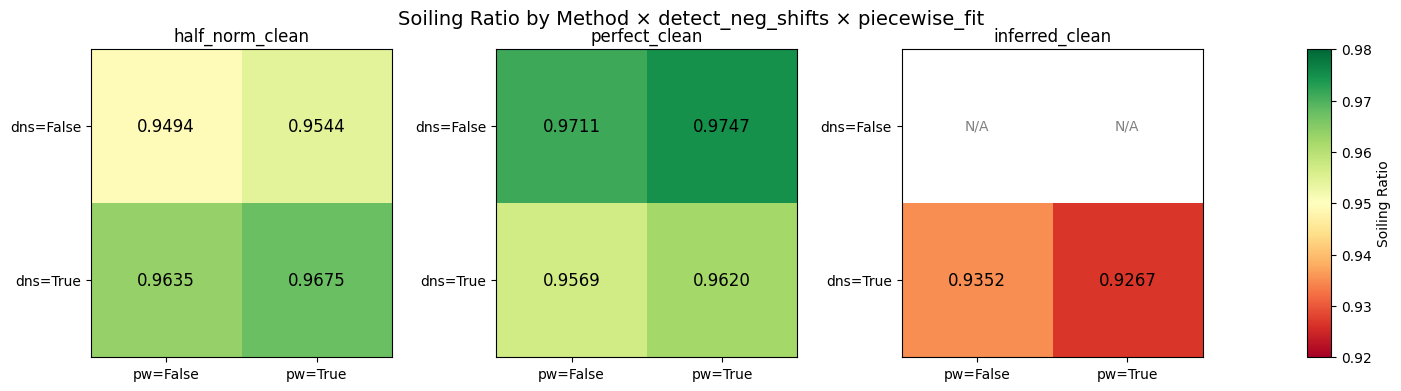

In [10]:
# Visualize soiling ratio by method and core options
valid_df = master_df[master_df['soiling_ratio'].notna()].copy()

# Focus on core_matrix group for main comparison
core_df = valid_df[valid_df['config_group'] == 'core_matrix'].copy()

# Create pivot for heatmap-style visualization with extra space for colorbar
fig = plt.figure(figsize=(16, 4))

# Create GridSpec with extra column for colorbar and more horizontal spacing
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 0.08], wspace=0.45)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])

for idx, method in enumerate(['half_norm_clean', 'perfect_clean', 'inferred_clean']):
    ax = axes[idx]
    method_data = core_df[core_df['method'] == method]

    # Create matrix for dns × pw
    pivot_data = []
    for dns in [False, True]:
        row = []
        for pw in [False, True]:
            if method == 'inferred_clean' and not dns:
                row.append(np.nan)
            else:
                val = method_data[(method_data['detect_neg_shifts'] == dns) &
                                  (method_data['piecewise_fit'] == pw)]['soiling_ratio']
                row.append(val.values[0] if len(val) > 0 else np.nan)
        pivot_data.append(row)

    pivot_arr = np.array(pivot_data)
    im = ax.imshow(pivot_arr, cmap='RdYlGn', vmin=0.92, vmax=0.98, aspect='auto')

    # Add text annotations
    for i in range(2):
        for j in range(2):
            if not np.isnan(pivot_arr[i, j]):
                ax.text(j, i, f'{pivot_arr[i, j]:.4f}', ha='center', va='center', fontsize=12)
            else:
                ax.text(j, i, 'N/A', ha='center', va='center', fontsize=10, color='gray')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['pw=False', 'pw=True'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['dns=False', 'dns=True'])
    ax.set_title(f'{method}')

fig.colorbar(im, cax=cax, label='Soiling Ratio')
fig.suptitle('Soiling Ratio by Method × detect_neg_shifts × piecewise_fit', fontsize=14)
plt.show()

C:\Users\mspringe\AppData\Local\Temp\1\ipykernel_13060\703968651.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(data_by_method, labels=methods, patch_artist=True)
C:\Users\mspringe\AppData\Local\Temp\1\ipykernel_13060\703968651.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_by_group, labels=groups, patch_artist=True)


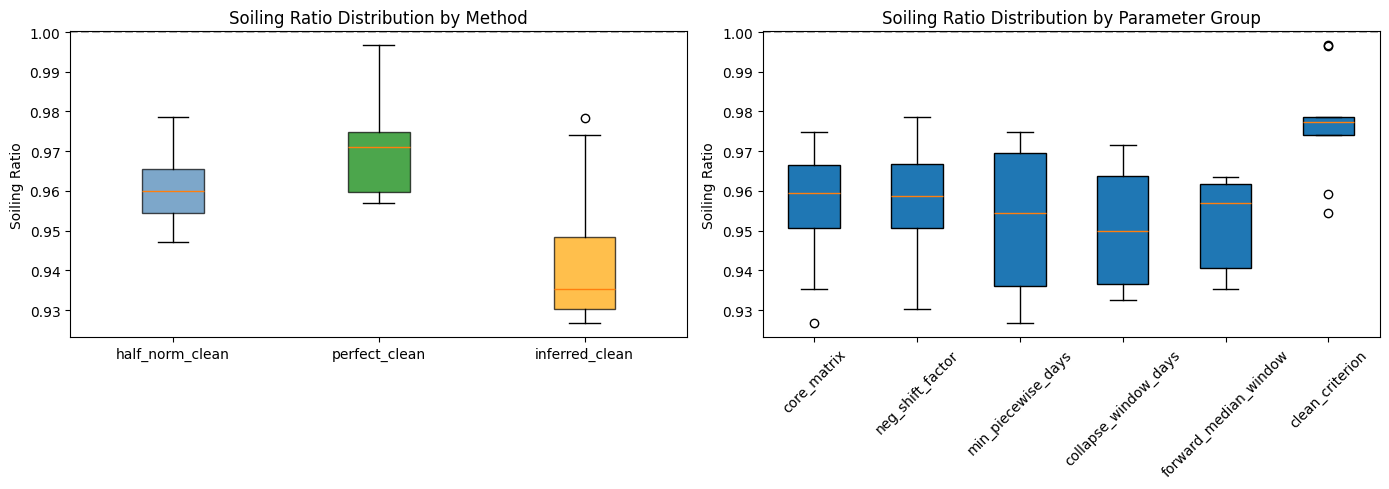

In [11]:
# Box plot of soiling ratio by method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by method
ax1 = axes[0]
methods = ['half_norm_clean', 'perfect_clean', 'inferred_clean']
data_by_method = [valid_df[valid_df['method'] == m]['soiling_ratio'].values for m in methods]
bp1 = ax1.boxplot(data_by_method, labels=methods, patch_artist=True)
colors = ['steelblue', 'green', 'orange']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Soiling Ratio')
ax1.set_title('Soiling Ratio Distribution by Method')
ax1.axhline(1.0, color='k', linestyle='--', alpha=0.3)

# Box plot by config group
ax2 = axes[1]
groups = valid_df['config_group'].unique()
data_by_group = [valid_df[valid_df['config_group'] == g]['soiling_ratio'].values for g in groups]
bp2 = ax2.boxplot(data_by_group, labels=groups, patch_artist=True)
ax2.set_ylabel('Soiling Ratio')
ax2.set_title('Soiling Ratio Distribution by Parameter Group')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

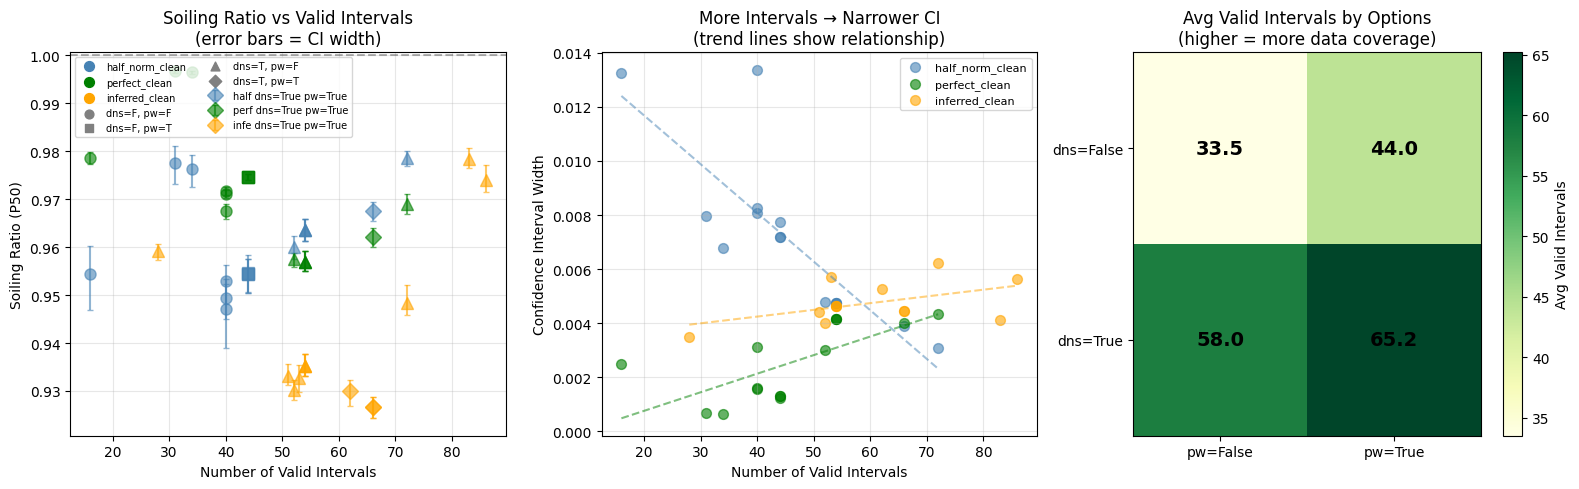


Key Insight: detect_neg_shifts=True typically finds MORE valid intervals,
which leads to narrower confidence intervals and more robust estimates.


In [ ]:
# Enhanced scatter plot: Soiling Ratio vs Valid Intervals with more context
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_map = {'half_norm_clean': 'steelblue', 'perfect_clean': 'green', 'inferred_clean': 'orange'}
markers_map = {(False, False): 'o', (False, True): 's', (True, False): '^', (True, True): 'D'}

# Plot 1: SR vs Valid Intervals with error bars and option markers
ax = axes[0]
for method, color in colors_map.items():
    for (dns, pw), marker in markers_map.items():
        subset = valid_df[(valid_df['method'] == method) &
                          (valid_df['detect_neg_shifts'] == dns) &
                          (valid_df['piecewise_fit'] == pw)]
        if len(subset) > 0:
            # Plot with error bars showing CI width
            ci_lower = subset['soiling_ratio'] - subset['ci_lower']
            ci_upper = subset['ci_upper'] - subset['soiling_ratio']
            ax.errorbar(subset['valid_intervals'], subset['soiling_ratio'],
                       yerr=[ci_lower, ci_upper], fmt=marker, color=color,
                       alpha=0.6, capsize=2, markersize=8,
                       label=f"{method[:4]} dns={dns} pw={pw}" if (dns, pw) == (True, True) else None)

# Add legend for methods and markers
for method, color in colors_map.items():
    ax.scatter([], [], c=color, label=method, s=50)
ax.scatter([], [], marker='o', c='gray', label='dns=F, pw=F', s=40)
ax.scatter([], [], marker='s', c='gray', label='dns=F, pw=T', s=40)
ax.scatter([], [], marker='^', c='gray', label='dns=T, pw=F', s=40)
ax.scatter([], [], marker='D', c='gray', label='dns=T, pw=T', s=40)

ax.set_xlabel('Number of Valid Intervals')
ax.set_ylabel('Soiling Ratio (P50)')
ax.set_title('Soiling Ratio vs Valid Intervals\n(error bars = CI width)')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.3, label='Perfect (1.0)')
ax.grid(True, alpha=0.3)

# Plot 2: CI Width vs Valid Intervals (uncertainty analysis)
ax = axes[1]
valid_df['ci_width'] = valid_df['ci_upper'] - valid_df['ci_lower']
for method, color in colors_map.items():
    subset = valid_df[valid_df['method'] == method]
    ax.scatter(subset['valid_intervals'], subset['ci_width'],
               label=method, alpha=0.6, s=50, c=color)
    # Add trend line
    if len(subset) > 2:
        z = np.polyfit(subset['valid_intervals'], subset['ci_width'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset['valid_intervals'].min(), subset['valid_intervals'].max(), 50)
        ax.plot(x_line, p(x_line), '--', color=color, alpha=0.5, linewidth=1.5)

ax.set_xlabel('Number of Valid Intervals')
ax.set_ylabel('Confidence Interval Width')
ax.set_title('More Intervals → Narrower CI\n(trend lines show relationship)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Heatmap of Valid Intervals by dns × pw
ax = axes[2]
pivot_intervals = valid_df.pivot_table(
    values='valid_intervals',
    index='detect_neg_shifts',
    columns='piecewise_fit',
    aggfunc='mean'
)
im = ax.imshow(pivot_intervals.values, cmap='YlGn', aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['pw=False', 'pw=True'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['dns=False', 'dns=True'])
for i in range(2):
    for j in range(2):
        val = pivot_intervals.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('Avg Valid Intervals by Options\n(higher = more data coverage)')
plt.colorbar(im, ax=ax, label='Avg Valid Intervals')

plt.tight_layout()
plt.show()

# Print key insight
print("\nKey Insight: detect_neg_shifts=True typically finds MORE valid intervals,")
print("which leads to narrower confidence intervals and more robust estimates.")

## Soiling Profile Comparison

Compare the daily soiling ratio profiles across different configurations.

Valid profiles: 43 out of 43


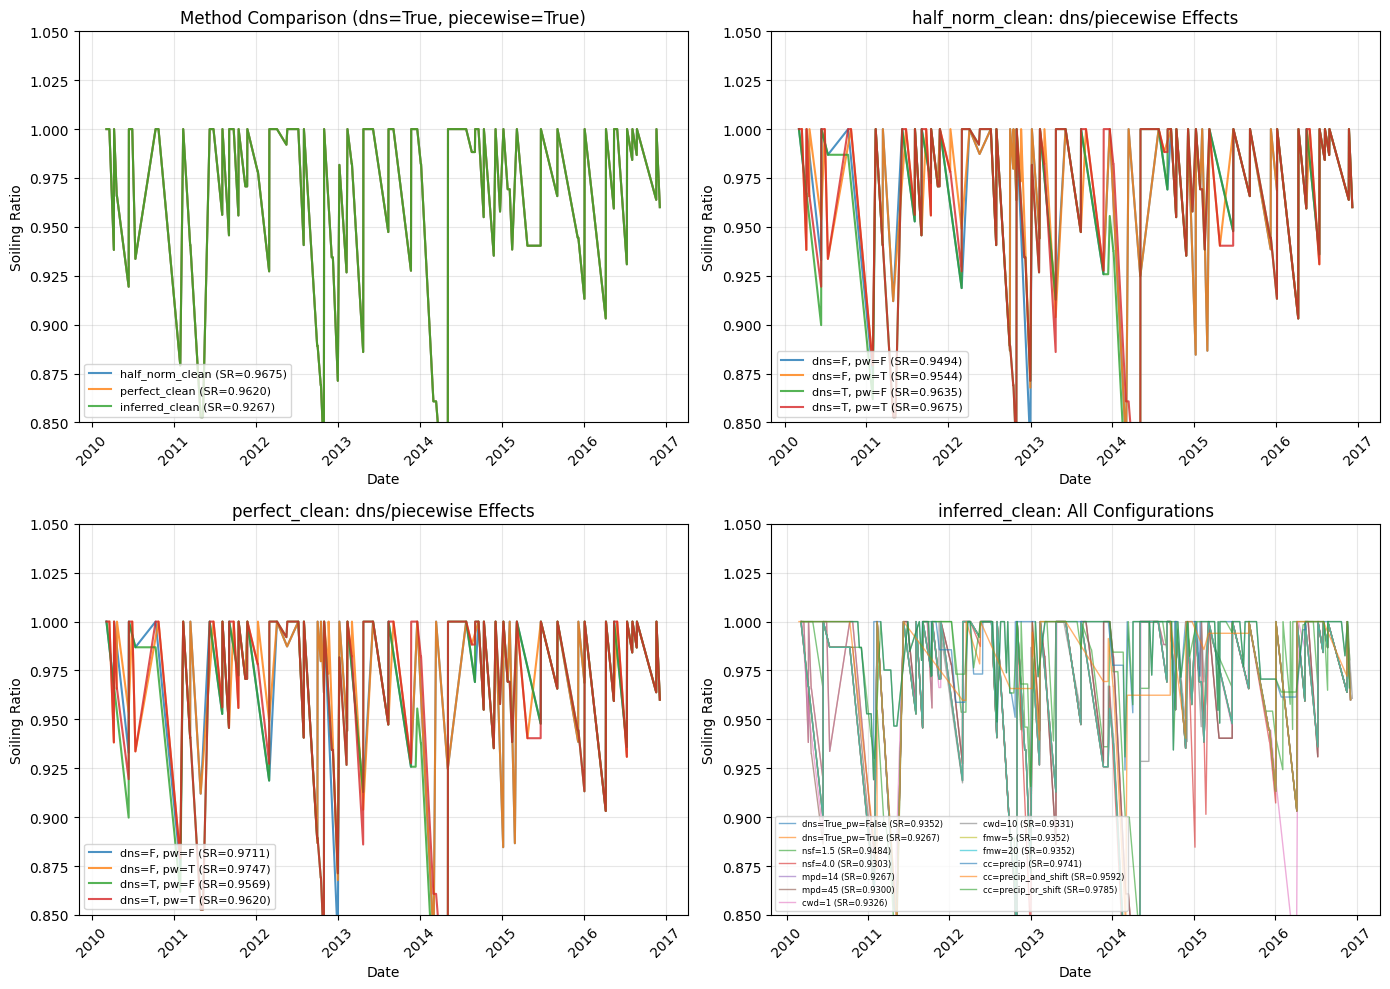

In [13]:
# Create a profiles dictionary keyed by config_id for easy lookup
profiles = {i: results[i]['sr_profile'] for i in range(len(results))
            if results[i]['sr_profile'] is not None and len(results[i]['sr_profile']) > 0}

print(f"Valid profiles: {len(profiles)} out of {len(results)}")

# Compare soiling profiles by method (using core matrix configurations)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Compare all 3 methods with default settings (dns=True, pw=True)
ax = axes[0, 0]
baseline_idx = master_df[(master_df['detect_neg_shifts'] == True) &
                         (master_df['piecewise_fit'] == True) &
                         (master_df['config_group'] == 'core_matrix')].index

for idx in baseline_idx:
    if idx in profiles:
        profile = profiles[idx]
        row = master_df.loc[idx]
        label = f"{row['method']} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('Method Comparison (dns=True, piecewise=True)')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 2: Compare detect_neg_shifts effect (half_norm_clean)
ax = axes[0, 1]
hnc_idx = master_df[(master_df['method'] == 'half_norm_clean') &
                    (master_df['config_group'] == 'core_matrix')].index

for idx in hnc_idx:
    if idx in profiles:
        profile = profiles[idx]
        row = master_df.loc[idx]
        dns_str = 'dns=T' if row['detect_neg_shifts'] else 'dns=F'
        pw_str = 'pw=T' if row['piecewise_fit'] else 'pw=F'
        label = f"{dns_str}, {pw_str} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('half_norm_clean: dns/piecewise Effects')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 3: Perfect clean with different settings
ax = axes[1, 0]
pc_idx = master_df[(master_df['method'] == 'perfect_clean') &
                   (master_df['config_group'] == 'core_matrix')].index

for idx in pc_idx:
    if idx in profiles:
        profile = profiles[idx]
        row = master_df.loc[idx]
        dns_str = 'dns=T' if row['detect_neg_shifts'] else 'dns=F'
        pw_str = 'pw=T' if row['piecewise_fit'] else 'pw=F'
        label = f"{dns_str}, {pw_str} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('perfect_clean: dns/piecewise Effects')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 4: Inferred clean (only works with dns=True)
ax = axes[1, 1]
ic_idx = master_df[(master_df['method'] == 'inferred_clean') &
                   (master_df['soiling_ratio'].notna())].index

for idx in ic_idx:
    if idx in profiles:
        profile = profiles[idx]
        row = master_df.loc[idx]
        config_short = row['config_name'].replace('inferred_clean_', '')[:20]
        label = f"{config_short} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.6, linewidth=1)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('inferred_clean: All Configurations')
ax.legend(loc='lower left', fontsize=6, ncol=2)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

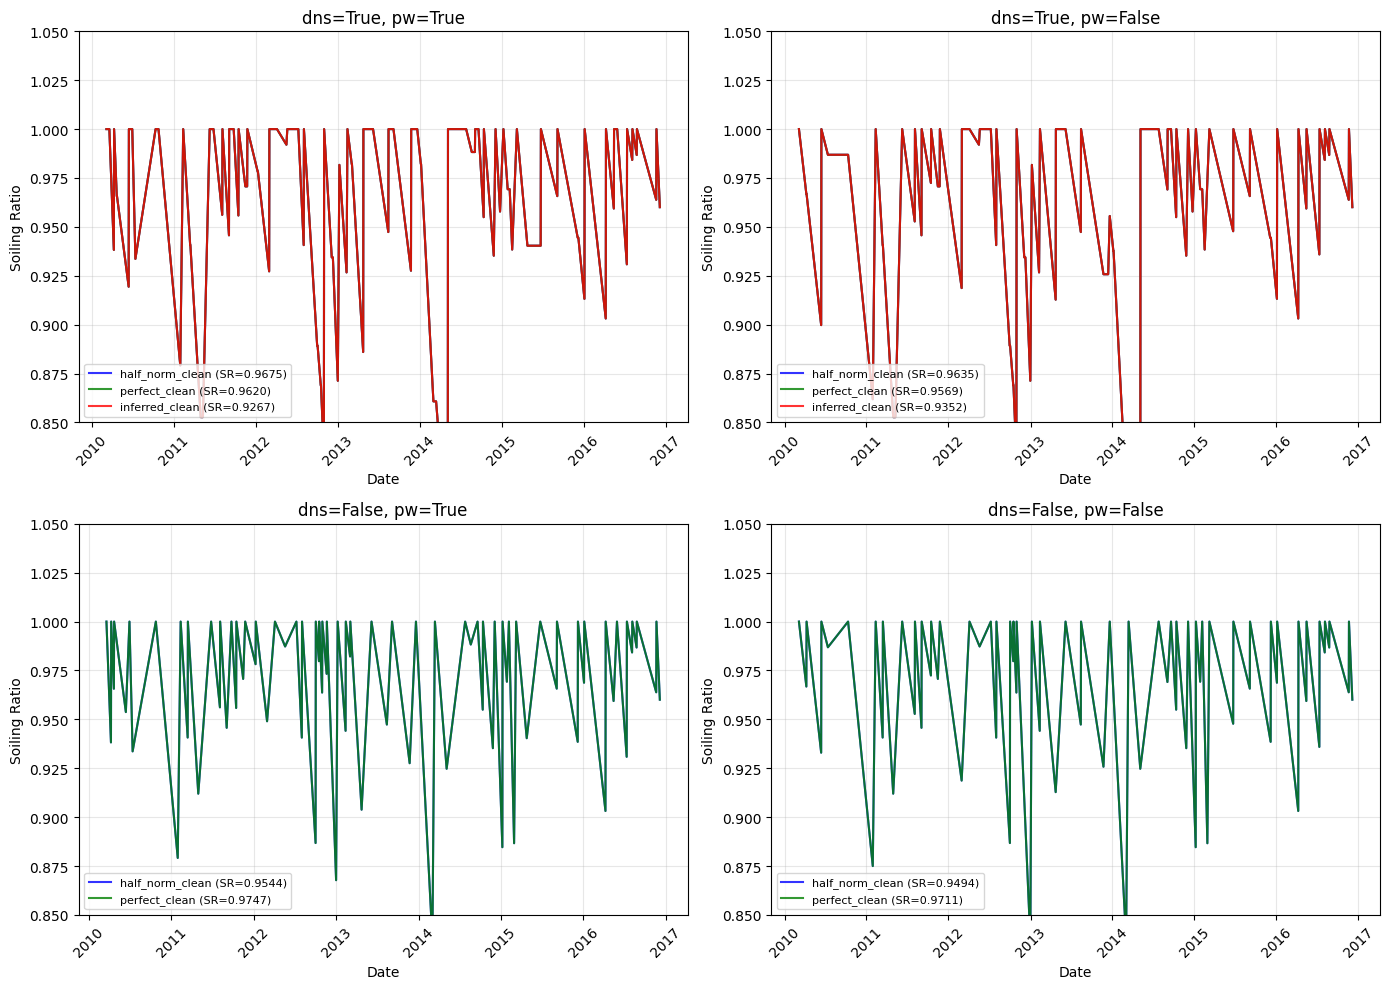

In [14]:
# Detailed profile comparison: overlay all methods with same core settings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Create a subplot for each (dns, pw) combination
settings = [(True, True), (True, False), (False, True), (False, False)]
colors_method = {'half_norm_clean': 'blue', 'perfect_clean': 'green', 'inferred_clean': 'red'}

for ax, (dns, pw) in zip(axes.flatten(), settings):
    subset_idx = master_df[(master_df['detect_neg_shifts'] == dns) &
                           (master_df['piecewise_fit'] == pw) &
                           (master_df['config_group'] == 'core_matrix')].index

    for idx in subset_idx:
        if idx in profiles:
            profile = profiles[idx]
            row = master_df.loc[idx]
            method = row['method']
            color = colors_method.get(method, 'gray')
            label = f"{method} (SR={row['soiling_ratio']:.4f})"
            ax.plot(profile.index, profile.values, label=label,
                    color=color, alpha=0.8, linewidth=1.5)

    ax.set_xlabel('Date')
    ax.set_ylabel('Soiling Ratio')
    dns_str = 'dns=True' if dns else 'dns=False'
    pw_str = 'pw=True' if pw else 'pw=False'
    ax.set_title(f'{dns_str}, {pw_str}')
    ax.legend(loc='lower left', fontsize=8)
    ax.set_ylim(0.85, 1.05)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Profile statistics: compare profile characteristics across methods
profile_stats = []
for idx in profiles:
    profile = profiles[idx]
    row = master_df.loc[idx]
    profile_stats.append({
        'method': row['method'],
        'config_name': row['config_name'],
        'dns': row['detect_neg_shifts'],
        'pw': row['piecewise_fit'],
        'profile_mean': profile.mean(),
        'profile_std': profile.std(),
        'profile_min': profile.min(),
        'profile_max': profile.max(),
        'profile_range': profile.max() - profile.min(),
        'n_points': len(profile),
        'aggregated_sr': row['soiling_ratio']
    })

profile_stats_df = pd.DataFrame(profile_stats)

# Summary by method
print("Profile Statistics by Method:")
print("="*60)
method_profile_summary = profile_stats_df.groupby('method').agg({
    'profile_mean': ['mean', 'std'],
    'profile_std': 'mean',
    'profile_range': 'mean',
    'n_points': 'mean',
    'aggregated_sr': 'mean'
}).round(4)
print(method_profile_summary.to_string())

# Key insight: correlation between profile mean and aggregated SR
print("\n\nCorrelation: Profile Mean vs Aggregated SR")
print("="*60)
for method in profile_stats_df['method'].unique():
    subset = profile_stats_df[profile_stats_df['method'] == method]
    corr = subset['profile_mean'].corr(subset['aggregated_sr'])
    print(f"{method}: r = {corr:.4f}")

Profile Statistics by Method:
                profile_mean         profile_std profile_range   n_points aggregated_sr
                        mean     std        mean          mean       mean          mean
method                                                                                 
half_norm_clean       0.9666  0.0084      0.0329        0.1858  1840.4000        0.9612
inferred_clean        0.9660  0.0116      0.0380        0.2074  2077.4615        0.9419
perfect_clean         0.9666  0.0084      0.0329        0.1858  1840.4000        0.9710


Correlation: Profile Mean vs Aggregated SR
half_norm_clean: r = 0.5403
perfect_clean: r = 0.9465
inferred_clean: r = 0.9392


## Stochastic Profile Comparison (Method-Specific)

The `soiling_ratio_perfect_clean` is the **same** for all methods - it's the deterministic profile. The actual method differences show up in the **stochastic Monte Carlo profiles**.

Valid stochastic profiles: 43 out of 43


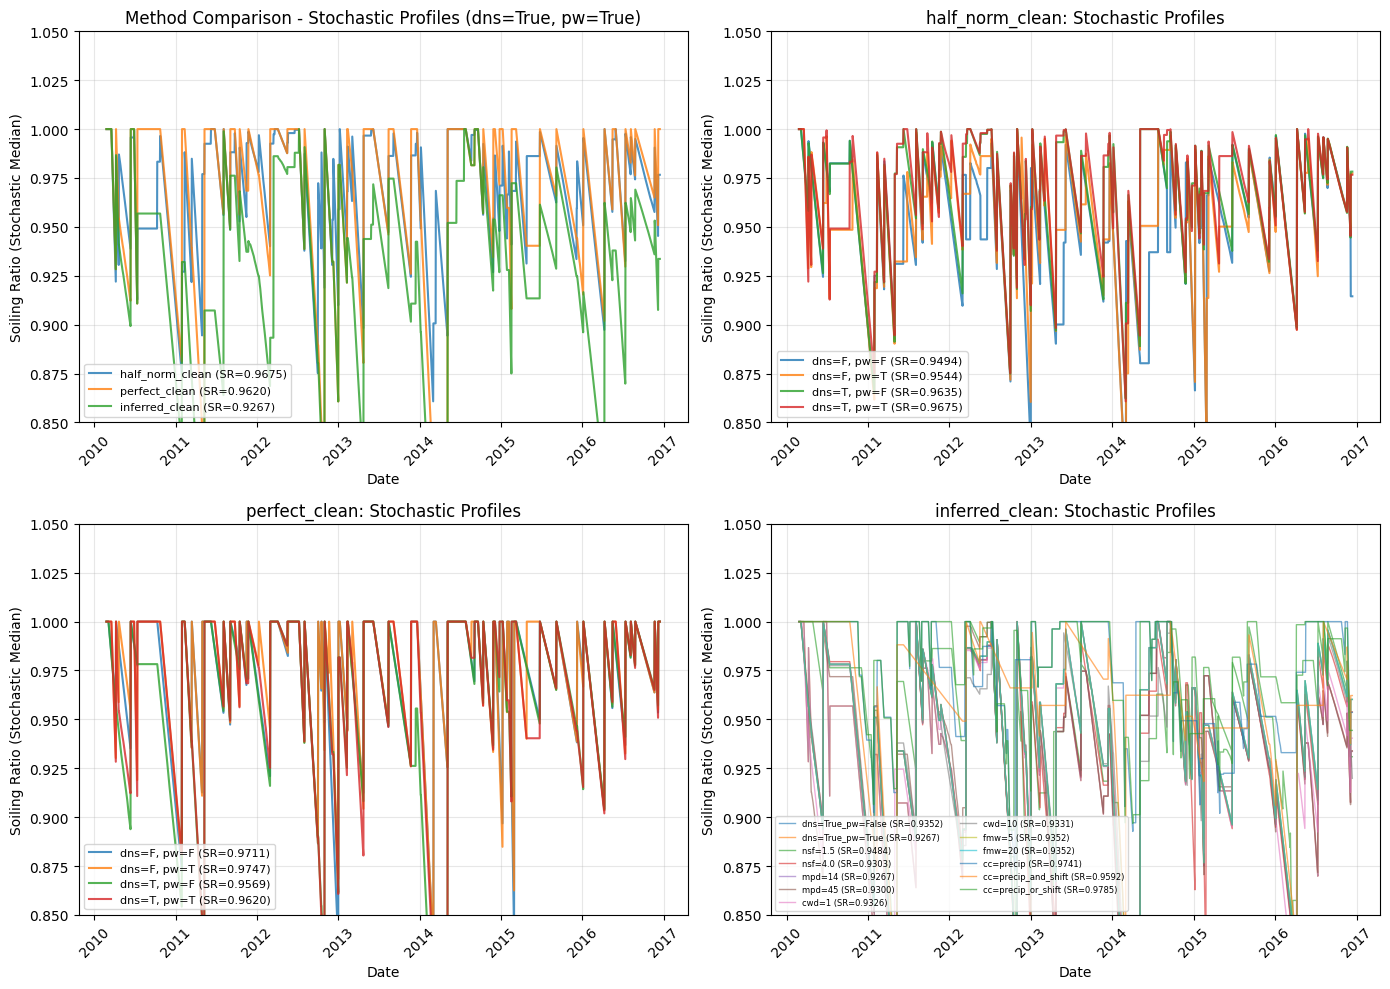

In [16]:
# Create stochastic profiles dictionary
stoch_profiles = {i: results[i]['stoch_profile'] for i in range(len(results))
                  if results[i]['stoch_profile'] is not None and len(results[i]['stoch_profile']) > 0}

print(f"Valid stochastic profiles: {len(stoch_profiles)} out of {len(results)}")

# Compare STOCHASTIC profiles by method (these show method differences!)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Compare all 3 methods with default settings (dns=True, pw=True)
ax = axes[0, 0]
baseline_idx = master_df[(master_df['detect_neg_shifts'] == True) &
                         (master_df['piecewise_fit'] == True) &
                         (master_df['config_group'] == 'core_matrix')].index

for idx in baseline_idx:
    if idx in stoch_profiles:
        profile = stoch_profiles[idx]
        row = master_df.loc[idx]
        label = f"{row['method']} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio (Stochastic Median)')
ax.set_title('Method Comparison - Stochastic Profiles (dns=True, pw=True)')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 2: Compare detect_neg_shifts effect (half_norm_clean) - stochastic
ax = axes[0, 1]
hnc_idx = master_df[(master_df['method'] == 'half_norm_clean') &
                    (master_df['config_group'] == 'core_matrix')].index

for idx in hnc_idx:
    if idx in stoch_profiles:
        profile = stoch_profiles[idx]
        row = master_df.loc[idx]
        dns_str = 'dns=T' if row['detect_neg_shifts'] else 'dns=F'
        pw_str = 'pw=T' if row['piecewise_fit'] else 'pw=F'
        label = f"{dns_str}, {pw_str} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio (Stochastic Median)')
ax.set_title('half_norm_clean: Stochastic Profiles')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 3: Perfect clean with different settings - stochastic
ax = axes[1, 0]
pc_idx = master_df[(master_df['method'] == 'perfect_clean') &
                   (master_df['config_group'] == 'core_matrix')].index

for idx in pc_idx:
    if idx in stoch_profiles:
        profile = stoch_profiles[idx]
        row = master_df.loc[idx]
        dns_str = 'dns=T' if row['detect_neg_shifts'] else 'dns=F'
        pw_str = 'pw=T' if row['piecewise_fit'] else 'pw=F'
        label = f"{dns_str}, {pw_str} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio (Stochastic Median)')
ax.set_title('perfect_clean: Stochastic Profiles')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 4: Inferred clean - stochastic
ax = axes[1, 1]
ic_idx = master_df[(master_df['method'] == 'inferred_clean') &
                   (master_df['soiling_ratio'].notna())].index

for idx in ic_idx:
    if idx in stoch_profiles:
        profile = stoch_profiles[idx]
        row = master_df.loc[idx]
        config_short = row['config_name'].replace('inferred_clean_', '')[:20]
        label = f"{config_short} (SR={row['soiling_ratio']:.4f})"
        ax.plot(profile.index, profile.values, label=label, alpha=0.6, linewidth=1)

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio (Stochastic Median)')
ax.set_title('inferred_clean: Stochastic Profiles')
ax.legend(loc='lower left', fontsize=6, ncol=2)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Summary Table

In [17]:
# Full results summary - sorted by soiling ratio
print("All Results Sorted by Soiling Ratio (highest to lowest):")
print("="*80)
sort_cols = ['config_name', 'method', 'detect_neg_shifts', 'piecewise_fit',
             'soiling_ratio', 'ci_lower', 'ci_upper', 'valid_intervals']
valid_df[sort_cols].sort_values('soiling_ratio', ascending=False).head(30)

All Results Sorted by Soiling Ratio (highest to lowest):


,config_name,method,detect_neg_shifts,piecewise_fit,soiling_ratio,ci_lower,ci_upper,valid_intervals
35,perfect_clean_cc=precip,perfect_clean,False,False,0.996671,0.996335,0.997030,31
41,perfect_clean_cc=precip_or_shift,perfect_clean,False,False,0.996448,0.996157,0.996813,34
10,half_norm_clean_nsf=1.5,half_norm_clean,True,False,0.978627,0.976994,0.980072,72
38,perfect_clean_cc=precip_and_shift,perfect_clean,False,False,0.978609,0.977383,0.979880,16
42,inferred_clean_cc=precip_or_shift,inferred_clean,True,False,0.978480,0.976462,0.980594,83
34,half_norm_clean_cc=precip,half_norm_clean,False,False,0.977473,0.973107,0.981068,31
40,half_norm_clean_cc=precip_or_shift,half_norm_clean,False,False,0.976294,0.972542,0.979310,34
3,perfect_clean_dns=False_pw=True,perfect_clean,False,True,0.974720,0.974031,0.975351,44
17,perfect_clean_mpd=14,perfect_clean,False,True,0.974720,0.974031,0.975351,44
20,perfect_clean_mpd=45,perfect_clean,False,True,0.974551,0.973916,0.975158,44


## Ground Truth Comparison

Since this dataset includes a **synthetic soiling signal** (the `soiling` column), we can directly compare the estimated soiling profiles to the known ground truth. This allows us to quantitatively evaluate which parameter configurations most accurately recover the true soiling behavior.

In [18]:
# Extract the ground truth soiling signal (daily aggregated)
ground_truth = df['soiling'].resample('D').mean()
ground_truth = ground_truth.reindex(energy_normalized_daily.index)

# Calculate the "true" aggregated soiling ratio for comparison
true_soiling_ratio = ground_truth.mean()
print(f"Ground Truth Mean Soiling Ratio: {true_soiling_ratio:.4f}")
print(f"Ground Truth Range: {ground_truth.min():.4f} - {ground_truth.max():.4f}")
print(f"\nNote: A 'perfect' soiling estimate would match {true_soiling_ratio:.4f}")

Ground Truth Mean Soiling Ratio: 0.9593
Ground Truth Range: 0.7589 - 1.0000

Note: A 'perfect' soiling estimate would match 0.9593


In [ ]:
# Calculate error metrics for each configuration
# Compare the STOCHASTIC profile (median Monte Carlo) to ground truth
error_metrics = []

for idx, row in master_df.iterrows():
    if idx in stoch_profiles and stoch_profiles[idx] is not None and len(stoch_profiles[idx]) > 0:
        estimated = stoch_profiles[idx]

        # Align to ground truth index
        common_idx = estimated.index.intersection(ground_truth.dropna().index)
        if len(common_idx) > 30:  # Need enough data points
            est_aligned = estimated.loc[common_idx]
            gt_aligned = ground_truth.loc[common_idx]

            # Calculate error metrics
            abs_error = (est_aligned - gt_aligned).abs()
            mae = abs_error.mean()
            rmse = np.sqrt(((est_aligned - gt_aligned) ** 2).mean())
            mape = (abs_error / gt_aligned.abs()).mean() * 100  # Mean Absolute Percentage Error
            correlation = est_aligned.corr(gt_aligned)
            bias = (est_aligned - gt_aligned).mean()  # Positive = overestimates

            # Compare aggregated soiling ratio to true mean
            sr_error = abs(row['soiling_ratio'] - true_soiling_ratio) if pd.notna(row['soiling_ratio']) else np.nan

            error_metrics.append({
                'config_idx': idx,
                'config_name': row['config_name'],
                'method': row['method'],
                'detect_neg_shifts': row['detect_neg_shifts'],
                'piecewise_fit': row['piecewise_fit'],
                'soiling_ratio': row['soiling_ratio'],
                'mae': mae,
                'rmse': rmse,
                'mape': mape,
                'correlation': correlation,
                'bias': bias,
                'sr_error': sr_error,
                'n_points': len(common_idx)
            })

error_df = pd.DataFrame(error_metrics)
print(f"Evaluated {len(error_df)} configurations against ground truth")
print(f"\nBest configurations by MAE (Mean Absolute Error):")
print(error_df.nsmallest(10, 'mae')[['config_name', 'method', 'detect_neg_shifts', 'piecewise_fit',
                                      'soiling_ratio', 'mae', 'rmse', 'correlation']].to_string())

Evaluated 43 configurations against ground truth

Best configurations by MAE (Mean Absolute Error):
                          config_name           method  detect_neg_shifts  piecewise_fit  soiling_ratio       mae      rmse  correlation
8      perfect_clean_dns=True_pw=True    perfect_clean               True           True       0.962020  0.016937  0.024695     0.847126
14              perfect_clean_nsf=4.0    perfect_clean               True          False       0.957464  0.018614  0.026003     0.858119
5     perfect_clean_dns=True_pw=False    perfect_clean               True          False       0.956869  0.019068  0.027656     0.853696
29                perfect_clean_fmw=5    perfect_clean               True          False       0.956869  0.019068  0.027656     0.853696
32               perfect_clean_fmw=20    perfect_clean               True          False       0.956869  0.019068  0.027656     0.853696
11              perfect_clean_nsf=1.5    perfect_clean               True     

C:\Users\mspringe\AppData\Local\Temp\1\ipykernel_13060\4202291704.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(method_errors, labels=methods, patch_artist=True)


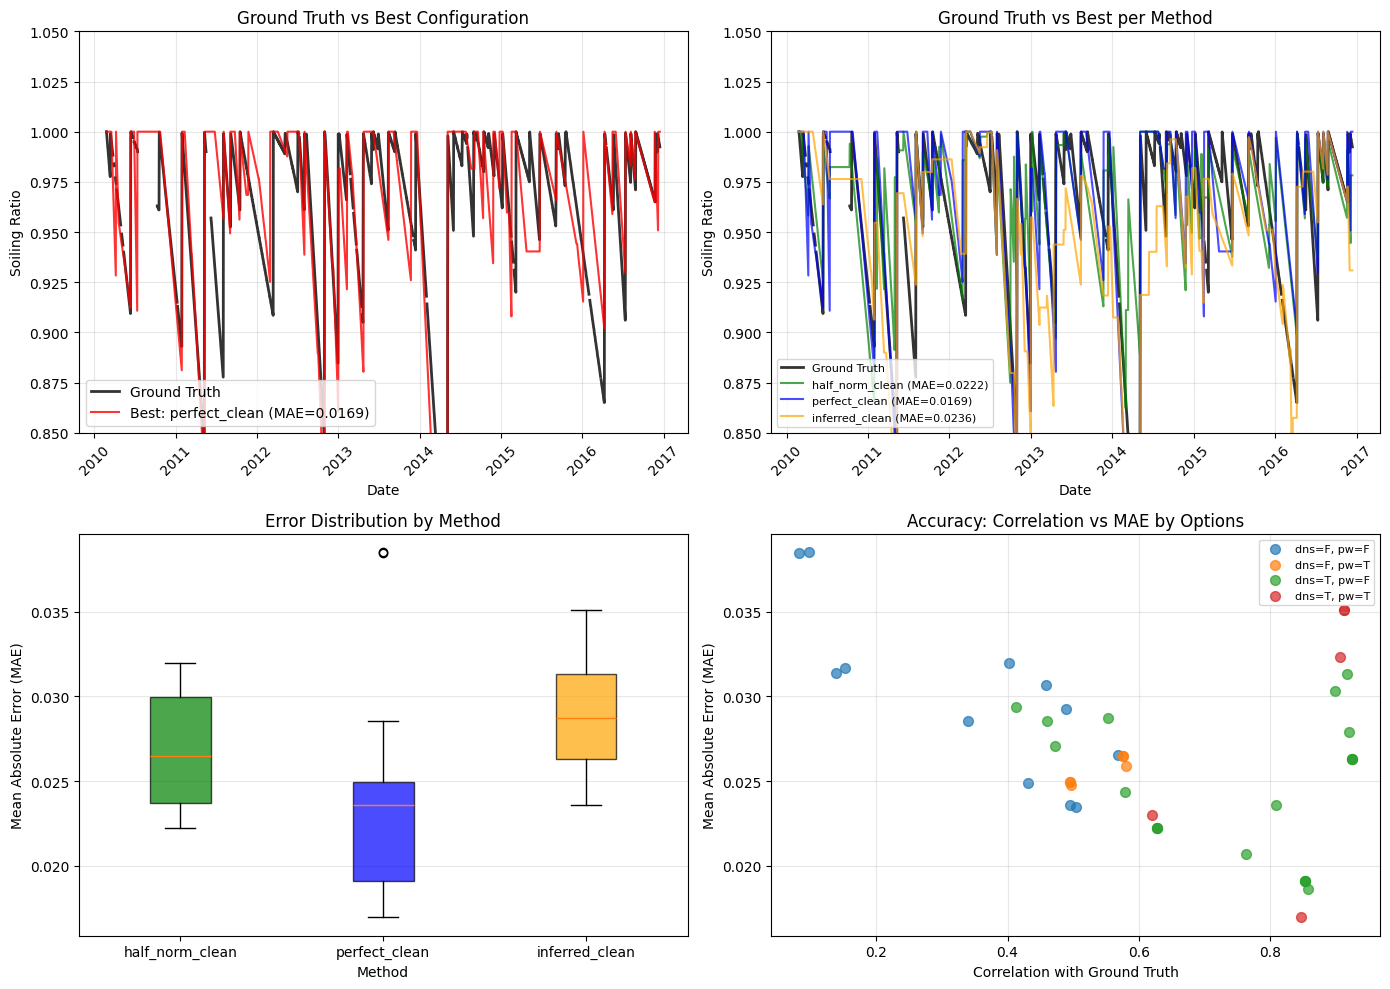

In [20]:
# Visualize: Compare best profiles to ground truth
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Ground Truth vs Best Overall Configuration
ax = axes[0, 0]
ax.plot(ground_truth.index, ground_truth.values, 'k-', linewidth=2, label='Ground Truth', alpha=0.8)

if len(error_df) > 0:
    best_idx = error_df.nsmallest(1, 'mae')['config_idx'].values[0]
    best_profile = stoch_profiles[best_idx]
    best_row = master_df.loc[best_idx]
    ax.plot(best_profile.index, best_profile.values, 'r-', linewidth=1.5, alpha=0.8,
            label=f"Best: {best_row['method']} (MAE={error_df.loc[error_df['config_idx']==best_idx, 'mae'].values[0]:.4f})")

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('Ground Truth vs Best Configuration')
ax.legend(loc='lower left')
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 2: Ground Truth vs Best per Method
ax = axes[0, 1]
ax.plot(ground_truth.index, ground_truth.values, 'k-', linewidth=2, label='Ground Truth', alpha=0.8)

colors = {'perfect_clean': 'blue', 'half_norm_clean': 'green', 'inferred_clean': 'orange'}
for method in error_df['method'].unique():
    method_best = error_df[error_df['method'] == method].nsmallest(1, 'mae')
    if len(method_best) > 0:
        idx = method_best['config_idx'].values[0]
        if idx in stoch_profiles:
            profile = stoch_profiles[idx]
            mae_val = method_best['mae'].values[0]
            ax.plot(profile.index, profile.values, color=colors.get(method, 'gray'),
                    linewidth=1.5, alpha=0.7, label=f"{method} (MAE={mae_val:.4f})")

ax.set_xlabel('Date')
ax.set_ylabel('Soiling Ratio')
ax.set_title('Ground Truth vs Best per Method')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0.85, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 3: Error Distribution by Method
ax = axes[1, 0]
methods = error_df['method'].unique()
method_errors = [error_df[error_df['method'] == m]['mae'].values for m in methods]
bp = ax.boxplot(method_errors, labels=methods, patch_artist=True)
for patch, method in zip(bp['boxes'], methods):
    patch.set_facecolor(colors.get(method, 'lightgray'))
    patch.set_alpha(0.7)
ax.set_xlabel('Method')
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('Error Distribution by Method')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Impact of detect_neg_shifts and piecewise_fit on accuracy
ax = axes[1, 1]
# Group by configuration options
for (dns, pw), group in error_df.groupby(['detect_neg_shifts', 'piecewise_fit']):
    dns_str = 'dns=T' if dns else 'dns=F'
    pw_str = 'pw=T' if pw else 'pw=F'
    label = f"{dns_str}, {pw_str}"
    ax.scatter(group['correlation'], group['mae'], label=label, alpha=0.7, s=50)

ax.set_xlabel('Correlation with Ground Truth')
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('Accuracy: Correlation vs MAE by Options')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Summary statistics: Which options give best ground-truth accuracy?
print("="*80)
print("GROUND TRUTH ACCURACY SUMMARY")
print("="*80)

# By method
print("\n1. By Method (mean MAE):")
method_summary = error_df.groupby('method')['mae'].agg(['mean', 'std', 'min']).round(4)
method_summary.columns = ['Mean MAE', 'Std MAE', 'Best MAE']
print(method_summary.sort_values('Mean MAE'))

# By detect_neg_shifts
print("\n2. By detect_neg_shifts:")
dns_summary = error_df.groupby('detect_neg_shifts')['mae'].agg(['mean', 'std', 'count']).round(4)
dns_summary.columns = ['Mean MAE', 'Std MAE', 'Count']
print(dns_summary)

# By piecewise_fit
print("\n3. By piecewise_fit:")
pw_summary = error_df.groupby('piecewise_fit')['mae'].agg(['mean', 'std', 'count']).round(4)
pw_summary.columns = ['Mean MAE', 'Std MAE', 'Count']
print(pw_summary)

# By combination
print("\n4. By Options Combination (detect_neg_shifts, piecewise_fit):")
combo_summary = error_df.groupby(['detect_neg_shifts', 'piecewise_fit'])['mae'].agg(['mean', 'std', 'min', 'count']).round(4)
combo_summary.columns = ['Mean MAE', 'Std MAE', 'Best MAE', 'Count']
print(combo_summary.sort_values('Mean MAE'))

# Best overall configuration
print("\n" + "="*80)
print("TOP 5 CONFIGURATIONS (Lowest MAE):")
print("="*80)
top5 = error_df.nsmallest(5, 'mae')
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"\n{i}. {row['config_name']}")
    print(f"   Method: {row['method']}, detect_neg_shifts={row['detect_neg_shifts']}, piecewise_fit={row['piecewise_fit']}")
    print(f"   MAE={row['mae']:.4f}, RMSE={row['rmse']:.4f}, Correlation={row['correlation']:.4f}")
    print(f"   Soiling Ratio: {row['soiling_ratio']:.4f} (True: {true_soiling_ratio:.4f}, Error: {row['sr_error']:.4f})")

GROUND TRUTH ACCURACY SUMMARY

1. By Method (mean MAE):
                 Mean MAE  Std MAE  Best MAE
method                                      
perfect_clean      0.0244   0.0066    0.0169
half_norm_clean    0.0269   0.0036    0.0222
inferred_clean     0.0292   0.0035    0.0236

2. By detect_neg_shifts:
                   Mean MAE  Std MAE  Count
detect_neg_shifts                          
False                0.0285   0.0046     18
True                 0.0254   0.0052     25

3. By piecewise_fit:
               Mean MAE  Std MAE  Count
piecewise_fit                          
False            0.0266   0.0051     32
True             0.0269   0.0054     11

4. By Options Combination (detect_neg_shifts, piecewise_fit):
                                 Mean MAE  Std MAE  Best MAE  Count
detect_neg_shifts piecewise_fit                                    
True              False            0.0247   0.0041    0.0186     20
False             True             0.0256   0.0008    0.0248      6


## Recommendations

Based on the analysis:

1. **For sites with irregular/natural cleaning**: Enable `detect_neg_shifts=True` with `method='perfect_clean'` or `method='inferred_clean'`
2. **For sites with gradual soiling changes**: Enable `piecewise_fit=True` to detect slope change points within intervals
3. **When precipitation data is available**: Use `clean_criterion='precip_or_shift'` for more cleaning event detection
4. **For noisy data**: Increase `neg_shift_factor` (e.g., 4.0) to reduce false positive negative shift detections
5. **For partial cleaning events**: Use `method='inferred_clean'` with `detect_neg_shifts=True` to infer recovery from data
6. **Using both options together** (`detect_neg_shifts=True` + `piecewise_fit=True`) generally provides more accurate results by detecting more valid soiling intervals

### Method Compatibility Notes:
- `method='inferred_clean'` **requires** `detect_neg_shifts=True`
- `method='perfect_clean'` and `method='inferred_clean'` use enhanced logic when `detect_neg_shifts=True`
- The old `perfect_clean_complex` and `inferred_clean_complex` methods have been replaced by the combination of base methods with `detect_neg_shifts=True` and `piecewise_fit=True`